In [39]:
import pandas as pd
import numpy as np

In [40]:
sentences = pd.read_csv('../data/sentences_with_metadata_order_singles_fixed_and_middles.csv')
len(sentences)

1057929

In [41]:
filtered_sentences = sentences

In [42]:
num_none_speakers = sentences['speaker'].isna().sum()
percentage_none_speakers = (num_none_speakers / len(sentences)) * 100
print(f"Number of rows with speaker = None: {num_none_speakers}")
print(f"Percentage of rows with speaker = None: {percentage_none_speakers:.2f}%")

Number of rows with speaker = None: 219165
Percentage of rows with speaker = None: 20.72%


In [ ]:
# episode_details = pd.read_csv('../data/episodes_with_id.csv')
# with open('../data/good_episode_ids.txt', 'r') as file:
#     good_episode_ids = file.read().splitlines()
# episode_details['episode_id'] = episode_details['episode_id'].astype(str)
# good_episode_ids = [str(eid) for eid in good_episode_ids]
# rj_episodes = episode_details[episode_details['episode_id'].isin(good_episode_ids)]
# len(rj_episodes)

In [ ]:
# multi_rj_episodes = rj_episodes[rj_episodes['totalSpLabels'] != 1]
# len(multi_rj_episodes)

In [ ]:
# sentences['episode_id'] = sentences['episode_id'].astype(int)
# multi_rj_episodes.loc[:, 'episode_id'] = multi_rj_episodes['episode_id'].astype(int)
# filtered_sentences = sentences[sentences['episode_id'].isin(multi_rj_episodes['episode_id'])]
# len(filtered_sentences)

In [45]:
speaker_counts = filtered_sentences['newSpeaker'].value_counts()
print(speaker_counts)

newSpeaker
SPEAKER_01    372518
SPEAKER_00    362510
SPEAKER_02     73263
SPEAKER_03     20125
SPEAKER_04      7428
SPEAKER_05      2159
SPEAKER_06       599
SPEAKER_08        64
SPEAKER_07        52
SPEAKER_09        46
Name: count, dtype: int64


In [46]:
num_none_speakers = filtered_sentences['speaker'].isna().sum()
percentage_none_speakers = (num_none_speakers / len(filtered_sentences)) * 100
print(f"Number of rows with speaker = None: {num_none_speakers}")
print(f"Percentage of rows with speaker = None: {percentage_none_speakers:.2f}%")

Number of rows with speaker = None: 219165
Percentage of rows with speaker = None: 20.72%


In [ ]:
# filtered_sentences = filtered_sentences.drop(columns=['time'])

In [47]:
filtered_sentences = filtered_sentences.reset_index(drop=True)

In [48]:
filtered_sentences.loc[filtered_sentences['racialJustice'] != 1, 'racialJustice'] = 0

In [49]:
filtered_sentences.loc[~((filtered_sentences['racialJustice'] == 1) & (filtered_sentences['collectiveAction'] == 0)), 'collectiveActionMulti'] = np.nan

### Assign metadata to n, NaN, n

In [50]:
for i in range(1, len(filtered_sentences) - 1): 
    try:
        if pd.isna(filtered_sentences.loc[i, 'speaker']):  # Check if 'speaker' is NaN
            prev_row = filtered_sentences.loc[i - 1]  # Previous row
            next_row = filtered_sentences.loc[i + 1]  # Next row
            
            if (prev_row['episode_id'] == next_row['episode_id'] and
                prev_row['speaker'] == next_row['speaker'] and
                prev_row['newSpeaker'] == next_row['newSpeaker'] and
                prev_row['turnCount'] == next_row['turnCount']):
            
                # Assign the metadata from the previous row to the current row
                columns_to_copy = [
                    'speaker', 'newSpeaker', 'mfcc1_sma3Mean', 'mfcc2_sma3Mean', 
                    'mfcc3_sma3Mean', 'mfcc4_sma3Mean', 'F0semitoneFrom27_5Hz_sma3nzMean', 
                    'F1frequency_sma3nzMean', 'startTime', 'endTime', 'duration', 'turnCount'
                ]
                
                for column in columns_to_copy:
                    filtered_sentences.loc[i, column] = prev_row[column]

    except KeyError:  # Handle case where the index does not exist
        #print(f"Skipping index {i} due to missing value.")
        continue  # Continue to the next iteration

In [51]:
num_none_speakers = filtered_sentences['speaker'].isna().sum()
percentage_none_speakers = (num_none_speakers / len(filtered_sentences)) * 100
print(f"Number of rows with speaker = None: {num_none_speakers}")
print(f"Percentage of rows with speaker = None: {percentage_none_speakers:.2f}%")

Number of rows with speaker = None: 219135
Percentage of rows with speaker = None: 20.71%


In [ ]:
#filtered_sentences.to_csv('../data/multi_speaker_sentences_3ormore.csv', index=False)

### Concatenate sentences
Everything from the first episode_id, turnCount to the last gets put into a paragraph

In [52]:
episodes = filtered_sentences #pd.read_csv('../data/multi_speaker_sentences_3ormore.csv')

In [53]:
episodes.loc[episodes['racialJustice'] == 0, 'collectiveAction'] = 1 # collectiveAction = 0 = True, racialJustice = 1 = True

In [54]:
# Forward fill and backward fill turnCount
fwd_fill = episodes['turnCount'].fillna(method='ffill')
bwd_fill = episodes['turnCount'].fillna(method='bfill')

# Ensure previous and next non-NaN rows have the same episode_id and turnCount
mask = (
    episodes['turnCount'].isna() &  # Only modify NaN rows
    (fwd_fill == bwd_fill) &  # Ensure turnCount values before and after match
    (episodes['episode_id'] == episodes['episode_id'].fillna(method='ffill')) &  # Ensure episode_id matches before
    (episodes['episode_id'] == episodes['episode_id'].fillna(method='bfill'))    # Ensure episode_id matches after
)

# Replace NaN values in turnCount where the condition holds
episodes.loc[mask, 'turnCount'] = fwd_fill[mask]

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_68945/2240775487.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fwd_fill = episodes['turnCount'].fillna(method='ffill')
/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_68945/2240775487.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  bwd_fill = episodes['turnCount'].fillna(method='bfill')
/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_68945/2240775487.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  (episodes['episode_id'] == episodes['episode_id'].fillna(method='ffill')) &  # Ensure episode_id matches before
/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_68945/2240775487.py:10: FutureWarning: Series.fillna with 'method'

In [55]:
num_none_speakers = episodes['turnCount'].isna().sum()
percentage_none_speakers = (num_none_speakers / len(episodes)) * 100
print(f"Number of rows with turnCount = None: {num_none_speakers}")
print(f"Percentage of rows with turnCount = None: {percentage_none_speakers:.2f}%")

Number of rows with turnCount = None: 191402
Percentage of rows with turnCount = None: 18.09%


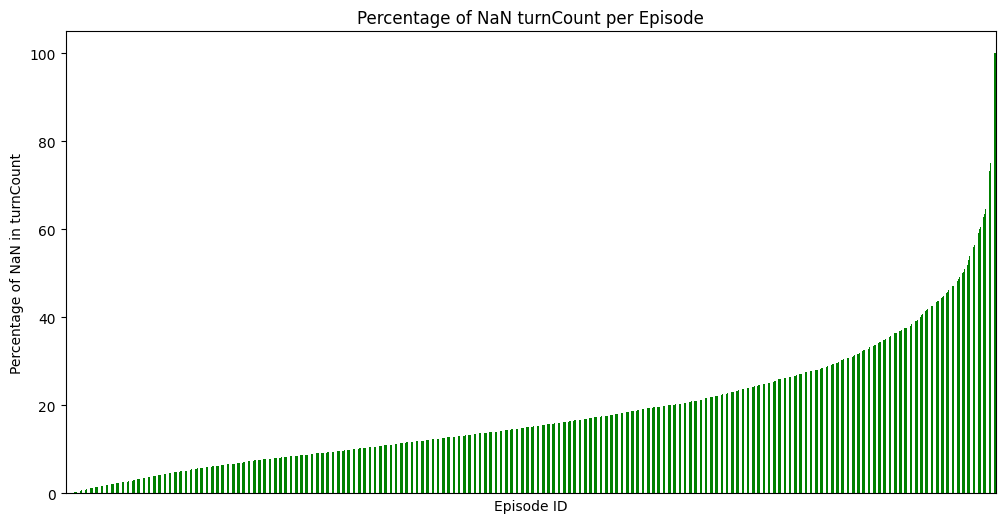

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by episode_id and calculate NaN percentage in turnCount
nan_percentages = episodes.groupby('episode_id')['turnCount'].apply(lambda x: x.isna().mean() * 100)

# Plot the results
plt.figure(figsize=(12, 6))
nan_percentages.sort_values().plot(kind='bar', color='green')
plt.xlabel("Episode ID")
plt.ylabel("Percentage of NaN in turnCount")
plt.title("Percentage of NaN turnCount per Episode")
plt.xticks([], [])
plt.show()

### Put paragraphs together 

In [57]:
import pandas as pd
import numpy as np

df = episodes  

# Initialize an empty list to store processed rows
processed_rows = []

# Loop through each unique episode_id
for episode in df['episode_id'].unique():
    episode_df = df[df['episode_id'] == episode]
    
    # Initialize tracking variables
    concatenated_text = ""
    current_group = []
    racialJustice_1_found = False
    collectiveAction_0_found = False
    collectiveAction_values = []
    
    previous_turnCount = None  # Track turnCount changes

    for _, row in episode_df.iterrows():
        turnCount = row['turnCount']

        # If turnCount changes or it's the first row, process the previous group
        if previous_turnCount is not None and previous_turnCount != turnCount:
            if current_group:
                # Assign computed values to the first row in the group
                current_group[0]['sentence'] = concatenated_text.strip()
                current_group[0]['racialJustice'] = int(racialJustice_1_found)
                current_group[0]['collectiveAction'] = 0 if collectiveAction_0_found else 1
                current_group[0]['collectiveActionMulti'] = (
                    collectiveAction_values if racialJustice_1_found and collectiveAction_0_found else np.nan
                )
                processed_rows.append(current_group[0])  # Save the grouped row

            # Reset variables for new turnCount group
            current_group = []
            concatenated_text = ""
            racialJustice_1_found = False
            collectiveAction_0_found = False
            collectiveAction_values = []

        # Collect sentence text
        concatenated_text += " " + row['sentence']
        
        # Track values for racialJustice and collectiveAction
        if row['racialJustice'] == 1:
            racialJustice_1_found = True
        if row['collectiveAction'] == 0:
            collectiveAction_0_found = True
        if pd.notna(row['collectiveActionMulti']):
            value = row['collectiveActionMulti']
            if isinstance(value, list):
                collectiveAction_values.extend(value)  # Maintain order and duplicates
            else:
                collectiveAction_values.append(value)

        current_group.append(row.to_dict())
        previous_turnCount = turnCount  # Update turn count tracker

    # Ensure the last group is added (including single-row cases)
    if current_group:
        current_group[0]['sentence'] = concatenated_text.strip()
        current_group[0]['racialJustice'] = int(racialJustice_1_found)
        current_group[0]['collectiveAction'] = 0 if collectiveAction_0_found else 1
        current_group[0]['collectiveActionMulti'] = (
            collectiveAction_values if racialJustice_1_found and collectiveAction_0_found else np.nan
        )
        processed_rows.append(current_group[0])

# Convert processed rows into DataFrame
df_processed = pd.DataFrame(processed_rows)

In [59]:
df_processed_not_nan = df_processed[df_processed['collectiveActionMulti'].notna()]
df_processed_not_nan.head(50)

,sentence,collectiveAction,racialJustice,collectiveActionMulti,episode_id,sentence_length,speaker,newSpeaker,mfcc1_sma3Mean,mfcc2_sma3Mean,mfcc3_sma3Mean,mfcc4_sma3Mean,F0semitoneFrom27_5Hz_sma3nzMean,F1frequency_sma3nzMean,startTime,endTime,duration,turnCount
8,"You can inherit good skin, pretty good health....",0,1,"[2.0, 3.0]",1,8,SPEAKER_02,SPEAKER_02,6.201177,0.733153,5.740260,2.000430,25.072135,734.913296,102.29,167.89,65.60,6.0
49,"And I think that the 70s, 80s was really that ...",0,1,[0.0],1,32,"SPEAKER_01, SPEAKER_00",SPEAKER_01,6.470220,17.569326,10.023670,22.290729,12.634379,831.267983,553.33,554.63,1.30,51.0
110,"And once they figured it out, they became supp...",0,1,[0.0],1,9,SPEAKER_01,SPEAKER_01,7.260685,5.539165,10.827754,14.638778,22.199633,768.743170,1181.86,2480.38,1298.52,107.0
115,"The title is, ""Don't Understand the Protests"" ...",0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",11,16,SPEAKER_01,SPEAKER_01,12.889864,7.751062,13.053939,-7.926472,14.395312,734.154573,151.02,464.68,313.66,6.0
120,"Really, obviously, good stuff from Kareem. So ...",0,1,"[3.0, 0.0, 0.0, 0.0, 1.0, 0.0]",11,6,SPEAKER_00,SPEAKER_00,22.089304,3.299921,1.235432,0.714483,14.806925,691.964086,525.20,858.28,333.08,9.0
133,"This is Fresh Shed, a weekly podcast that make...",0,1,[3.0],14,16,SPEAKER_01,SPEAKER_01,32.838177,11.001239,25.170367,12.035656,9.024397,746.749243,0.00,78.96,78.96,1.0
136,So that's why we're standing up every way we c...,0,1,"[3.0, 3.0, 0.0, 0.0, 3.0, 3.0, 0.0, 0.0, 0.0, ...",14,35,SPEAKER_00,SPEAKER_00,36.065502,-13.805387,14.654931,-9.197274,19.114727,718.933296,665.16,810.69,145.53,27.0
140,"She repeat Newton's body seals, the original f...",0,1,"[0.0, 0.0, 0.0, 0.0]",14,15,SPEAKER_00,SPEAKER_00,37.609832,-12.143121,13.008639,-10.027974,18.493013,704.282276,826.54,880.98,54.44,30.0
141,The elephant in the room is that 100 years ago...,0,1,[0.0],14,65,"SPEAKER_00, SPEAKER_01",SPEAKER_00,39.016462,-13.666471,13.439085,-19.584208,25.615676,747.528559,880.98,881.52,0.54,31.0
142,"So, you know, it was as good as usual for them...",0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",14,11,SPEAKER_00,SPEAKER_00,35.555946,-15.620539,19.291132,-7.163351,20.797440,727.909733,881.52,959.99,78.47,32.0


In [60]:
num_none_speakers = df_processed['turnCount'].isna().sum()
percentage_none_speakers = (num_none_speakers / len(df_processed)) * 100
print(f"Number of rows with turnCount = None: {num_none_speakers}")
print(f"Percentage of rows with turnCount = None: {percentage_none_speakers:.2f}%")

Number of rows with turnCount = None: 191402
Percentage of rows with turnCount = None: 55.48%


In [61]:
num_none_speakers = df_processed['newSpeaker'].isna().sum()
percentage_none_speakers = (num_none_speakers / len(df_processed)) * 100
print(f"Number of rows with newSpeaker = None: {num_none_speakers}")
print(f"Percentage of rows with newSpeaker = None: {percentage_none_speakers:.2f}%")

Number of rows with newSpeaker = None: 191402
Percentage of rows with newSpeaker = None: 55.48%


In [62]:
len(df_processed)

345022

In [63]:
df_processed.to_csv('../data/paragraph_turns.csv', index=False)

### Put paragraphs together (v2)

In [22]:
df_processed = pd.read_csv('../data/paragraph_turns.csv')

Assign turnCount to patterns such as n, NaN, NaN, NaN, n+4

In [64]:
def interpolate_turn_count(df):
    # Sort by episode_id and turnCount to ensure correct ordering

    def fill_turn_counts(group):
        turn_counts = group['turnCount'].values
        n = len(turn_counts)

        for i in range(n):
            if np.isnan(turn_counts[i]):  # If we encounter a NaN
                prev_idx = i - 1
                next_idx = i + 1

                # Find the previous non-NaN value
                while prev_idx >= 0 and np.isnan(turn_counts[prev_idx]):
                    prev_idx -= 1
                
                # Find the next non-NaN value
                while next_idx < n and np.isnan(turn_counts[next_idx]):
                    next_idx += 1

                if prev_idx >= 0 and next_idx < n:  # Ensure valid indices
                    prev_value = turn_counts[prev_idx]
                    next_value = turn_counts[next_idx]

                    # Calculate the number of missing values
                    gap = next_idx - prev_idx - 1
                    step_size = next_value - prev_value - 1

                    if gap == step_size:  # Only fill if the gap is valid
                        for j in range(1, gap + 1):
                            turn_counts[prev_idx + j] = prev_value + j

        group['turnCount'] = turn_counts
        return group

    return df.groupby('episode_id', group_keys=False).apply(fill_turn_counts)

# Apply the function
df_fixed = interpolate_turn_count(df_processed)

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_68945/2784956937.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('episode_id', group_keys=False).apply(fill_turn_counts)


In [65]:
num_none_speakers = df_fixed['turnCount'].isna().sum()
percentage_none_speakers = (num_none_speakers / len(df_processed)) * 100
print(f"Number of rows with turnCount = None: {num_none_speakers}")
print(f"Percentage of rows with turnCount = None: {percentage_none_speakers:.2f}%")

Number of rows with turnCount = None: 164619
Percentage of rows with turnCount = None: 47.71%


In [66]:
num_none_speakers = df_fixed['newSpeaker'].isna().sum()
percentage_none_speakers = (num_none_speakers / len(df_fixed)) * 100
print(f"Number of rows with newSpeaker = None: {num_none_speakers}")
print(f"Percentage of rows with newSpeaker = None: {percentage_none_speakers:.2f}%")

Number of rows with newSpeaker = None: 191402
Percentage of rows with newSpeaker = None: 55.48%


Assign metadata to newly-filled in turncounts

In [67]:
turns = []
num_turns_appended = 0

for episode_id in episodes['episode_id'].unique():
    file_path = f"../data/episodes/speaker_turns/episode_{episode_id}.csv"
    try:
        df_turn = pd.read_csv(file_path)
        df_turn['episode_id'] = episode_id
        turns.append(df_turn)
        num_turns_appended += 1
    except FileNotFoundError:
        continue

turns = pd.concat(turns, ignore_index=True)
print(f"Number of CSV files added to turns: {num_turns_appended}")

Number of CSV files added to turns: 3543


In [68]:
for index, row in df_fixed.iterrows():
    # Check if 'speaker' is NaN and 'turnCount' is not NaN
    if pd.isna(row['speaker']) and not pd.isna(row['turnCount']):
        episode_id = row['episode_id']
        turn_count = row['turnCount']
        
        # Find the corresponding row in the turns df with the same episode_id and turnCount
        matching_row = turns[(turns['episode_id'] == episode_id) & (turns['turnCount'] == turn_count)]
        
        if not matching_row.empty:
            # Update the columns in df_fixed based on the matching row from turns
            df_fixed.at[index, 'speaker'] = matching_row['speaker'].values[0]
            df_fixed.at[index, 'newSpeaker'] = matching_row['newSpeaker'].values[0]
            df_fixed.at[index, 'mfcc1_sma3Mean'] = matching_row['mfcc1_sma3Mean'].values[0]
            df_fixed.at[index, 'mfcc2_sma3Mean'] = matching_row['mfcc2_sma3Mean'].values[0]
            df_fixed.at[index, 'mfcc3_sma3Mean'] = matching_row['mfcc3_sma3Mean'].values[0]
            df_fixed.at[index, 'mfcc4_sma3Mean'] = matching_row['mfcc4_sma3Mean'].values[0]
            df_fixed.at[index, 'F0semitoneFrom27_5Hz_sma3nzMean'] = matching_row['F0semitoneFrom27_5Hz_sma3nzMean'].values[0]
            df_fixed.at[index, 'F1frequency_sma3nzMean'] = matching_row['F1frequency_sma3nzMean'].values[0]
            df_fixed.at[index, 'startTime'] = matching_row['startTime'].values[0]
            df_fixed.at[index, 'endTime'] = matching_row['endTime'].values[0]
            df_fixed.at[index, 'duration'] = matching_row['duration'].values[0]

In [70]:
df_fixed.to_csv('../data/paragraph_turns_with_patterns_filled.csv', index=False)

In [69]:
df_fixed[['speaker','newSpeaker','turnCount','episode_id']].head(50)

,speaker,newSpeaker,turnCount,episode_id
0,SPEAKER_00,SPEAKER_00,1.0,1
1,SPEAKER_02,SPEAKER_02,2.0,1
2,NaN,NaN,NaN,1
3,SPEAKER_00,SPEAKER_00,3.0,1
4,NaN,NaN,NaN,1
5,SPEAKER_02,SPEAKER_02,4.0,1
6,NaN,NaN,NaN,1
7,NaN,NaN,NaN,1
8,SPEAKER_02,SPEAKER_02,6.0,1
9,"SPEAKER_02, SPEAKER_01",SPEAKER_02,7.0,1


Check how many consecutive rows (by index) with the same episode_id and newSpeaker

In [71]:
# df_processed = pd.read_csv('../data/paragraph_turns.csv')
# df_fixed = pd.read_csv('../data/paragraph_turns_v2.csv')
df_processed = df_fixed

In [72]:
df_processed = df_processed.reset_index(drop=True)

In [ ]:
# different_rows = df_fixed[df_fixed['speaker'].fillna('MISSING') != df_processed['speaker'].fillna('MISSING')]
# different_rows

In [73]:
df_processed['streak'] = (df_processed[['episode_id', 'speaker']]
                          .ne(df_processed[['episode_id', 'speaker']].shift())
                          .any(axis=1)
                          .cumsum())

df_processed['streak_length'] = df_processed.groupby('streak')['streak'].transform('count')

In [74]:
df_processed[df_processed['streak_length'] > 1].groupby('streak_length').size()

streak_length
2    560
3     15
dtype: int64

In [75]:
total_streaks = df_processed[df_processed['streak_length'] > 1].groupby('streak_length').size().sum()
total_streaks

575

In [76]:
df_processed[df_processed['collectiveActionMulti'].notna()]

,sentence,collectiveAction,racialJustice,collectiveActionMulti,episode_id,sentence_length,speaker,newSpeaker,mfcc1_sma3Mean,mfcc2_sma3Mean,mfcc3_sma3Mean,mfcc4_sma3Mean,F0semitoneFrom27_5Hz_sma3nzMean,F1frequency_sma3nzMean,startTime,endTime,duration,turnCount,streak,streak_length
8,"You can inherit good skin, pretty good health....",0,1,"[2.0, 3.0]",1,8,SPEAKER_02,SPEAKER_02,6.201177,0.733153,5.740260,2.000430,25.072135,734.913296,102.29,167.89,65.60,6.0,9,1
49,"And I think that the 70s, 80s was really that ...",0,1,[0.0],1,32,"SPEAKER_01, SPEAKER_00",SPEAKER_01,6.470220,17.569326,10.023670,22.290729,12.634379,831.267983,553.33,554.63,1.30,51.0,50,1
110,"And once they figured it out, they became supp...",0,1,[0.0],1,9,SPEAKER_01,SPEAKER_01,7.260685,5.539165,10.827754,14.638778,22.199633,768.743170,1181.86,2480.38,1298.52,107.0,111,1
115,"The title is, ""Don't Understand the Protests"" ...",0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",11,16,SPEAKER_01,SPEAKER_01,12.889864,7.751062,13.053939,-7.926472,14.395312,734.154573,151.02,464.68,313.66,6.0,116,1
120,"Really, obviously, good stuff from Kareem. So ...",0,1,"[3.0, 0.0, 0.0, 0.0, 1.0, 0.0]",11,6,SPEAKER_00,SPEAKER_00,22.089304,3.299921,1.235432,0.714483,14.806925,691.964086,525.20,858.28,333.08,9.0,121,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344775,"There are, yeah, there are, I mean, there's pe...",0,1,[0.0],9990,10,SPEAKER_01,SPEAKER_01,22.997783,0.076042,1.115892,-20.328369,15.897125,705.120582,1107.91,1199.55,91.64,47.0,344486,1
344783,"Anyway, so I did not obviously buy that car. I...",0,1,[0.0],9993,9,SPEAKER_01,SPEAKER_01,29.330424,4.262492,18.895851,11.536657,12.570813,647.823164,141.28,880.16,738.88,3.0,344494,1
344833,But that project was really important because ...,0,1,[3.0],9995,41,SPEAKER_01,SPEAKER_01,22.685993,2.382473,4.127899,-13.188622,21.055622,700.885387,488.29,523.02,34.73,45.0,344544,1
344881,"Yeah, I'll start by saying that there really a...",0,1,[1.0],9995,11,SPEAKER_01,SPEAKER_01,24.190880,0.465543,1.264413,-12.195513,21.666384,729.048897,1007.35,1106.62,99.27,92.0,344592,1


In [78]:
df_processed[df_processed['streak_length'] > 1].head(10)

,sentence,collectiveAction,racialJustice,collectiveActionMulti,episode_id,sentence_length,speaker,newSpeaker,mfcc1_sma3Mean,mfcc2_sma3Mean,mfcc3_sma3Mean,mfcc4_sma3Mean,F0semitoneFrom27_5Hz_sma3nzMean,F1frequency_sma3nzMean,startTime,endTime,duration,turnCount,streak,streak_length
135,"In the United States, you cannot point to any ...",1,1,NaN,14,23,SPEAKER_00,SPEAKER_00,41.917752,-6.495941,20.564560,0.580897,12.735775,610.504132,79.60,104.61,25.01,3.0,136,2
136,So that's why we're standing up every way we c...,0,1,"[3.0, 3.0, 0.0, 0.0, 3.0, 3.0, 0.0, 0.0, 0.0, ...",14,35,SPEAKER_00,SPEAKER_00,36.065502,-13.805387,14.654931,-9.197274,19.114727,718.933296,665.16,810.69,145.53,27.0,136,2
1162,"Make sure to rate, comment, and subscribe and ...",1,0,NaN,131,16,SPEAKER_01,SPEAKER_01,20.709209,5.250423,16.253133,0.060767,19.913363,561.773844,663.91,673.85,9.94,205.0,1162,2
1163,You can follow us on Instagram @teanagefeverof...,1,0,NaN,131,7,SPEAKER_01,SPEAKER_01,18.043780,2.666081,13.153150,-3.942631,21.215963,608.711616,681.83,684.66,2.83,212.0,1162,2
6323,So I broke this down. I broke this down on soc...,0,1,[3.0],1164,5,SPEAKER_00,SPEAKER_00,25.422173,2.232033,7.171961,-21.099185,21.224113,674.914363,404.95,500.76,95.81,20.0,6322,2
6324,People take that heart and their soul and they...,1,0,NaN,1164,16,SPEAKER_00,SPEAKER_00,25.354641,1.142612,5.540841,-23.209154,19.663710,703.649278,501.68,511.87,10.19,22.0,6322,2
6796,And they get to talk about that. I've also see...,0,1,[3.0],1175,7,SPEAKER_00,SPEAKER_00,22.894058,0.283101,10.632887,-3.419168,14.256606,737.376542,1332.36,1410.57,78.21,101.0,6794,2
6797,And so they're all very conscious. And so I th...,0,1,"[0.0, 2.0, 0.0]",1175,6,SPEAKER_00,SPEAKER_00,25.052791,3.234985,10.554394,-9.896714,12.746167,689.283740,1411.14,1460.08,48.94,103.0,6794,2
6839,"- Yeah, no, no. You know, my kid, you know, mi...",1,0,NaN,1175,4,SPEAKER_00,SPEAKER_00,25.145864,-7.425876,11.717800,-13.859644,16.298687,744.572925,1979.20,1983.28,4.08,170.0,6836,2
6840,He's gonna be 10 months. He's gonna be 10 mont...,1,0,NaN,1175,5,SPEAKER_00,SPEAKER_00,25.563998,1.806049,9.992448,-9.449429,12.986562,714.998451,1983.95,2016.72,32.77,172.0,6836,2


In [ ]:
# df_processed['streak'] = (df_processed[['episode_id', 'newSpeaker']]
#                           .ne(df_processed[['episode_id', 'newSpeaker']].shift())
#                           .any(axis=1)
#                           .cumsum())

# df_processed['streak_length'] = df_processed.groupby('streak')['streak'].transform('count')

Concatenate consecutive rows with the same episode_id and newSpeaker

In [81]:
df_episode_14 = df_processed[df_processed['episode_id'] == 14]
df_episode_14.head(4)

,sentence,collectiveAction,racialJustice,collectiveActionMulti,episode_id,sentence_length,speaker,newSpeaker,mfcc1_sma3Mean,mfcc2_sma3Mean,mfcc3_sma3Mean,mfcc4_sma3Mean,F0semitoneFrom27_5Hz_sma3nzMean,F1frequency_sma3nzMean,startTime,endTime,duration,turnCount,streak,streak_length
133,"This is Fresh Shed, a weekly podcast that make...",0,1,[3.0],14,16,SPEAKER_01,SPEAKER_01,32.838177,11.001239,25.170367,12.035656,9.024397,746.749243,0.00,78.96,78.96,1.0,134,1
134,There's no evidence that dictates that black m...,1,0,NaN,14,13,"SPEAKER_01, SPEAKER_00",SPEAKER_01,38.594962,2.106446,27.342372,14.475232,12.401305,825.807356,78.96,79.60,0.64,2.0,135,1
135,"In the United States, you cannot point to any ...",1,1,NaN,14,23,SPEAKER_00,SPEAKER_00,41.917752,-6.495941,20.564560,0.580897,12.735775,610.504132,79.60,104.61,25.01,3.0,136,2
136,So that's why we're standing up every way we c...,0,1,"[3.0, 3.0, 0.0, 0.0, 3.0, 3.0, 0.0, 0.0, 0.0, ...",14,35,SPEAKER_00,SPEAKER_00,36.065502,-13.805387,14.654931,-9.197274,19.114727,718.933296,665.16,810.69,145.53,27.0,136,2


In [82]:
import math

# Initialize an empty list to store aggregated rows
aggregated_rows = []

# Temporary storage for the current group
current_group = None

# Iterate over the DataFrame row by row
for idx, row in df_processed.iterrows():
    if current_group is None:
        # Start a new group
        current_group = row.to_dict()

        # If curr list is NaN, replace with empty list
        curr_multi_list=row["collectiveActionMulti"]
        if isinstance(curr_multi_list, float):
            if not math.isnan(curr_multi_list):
                curr_multi_list = [curr_multi_list]
            else:
                curr_multi_list = []

        # # If curr list is NaN, replace with empty list
        # curr_speaker_list=row["newSpeaker"]
        # if curr_speaker_list is None:
        #     curr_speaker_list = []
        # elif isinstance(curr_speaker_list, str):
        #     curr_speaker_list = [curr_speaker_list]

        current_group["collectiveActionMulti"] = curr_multi_list
        # current_group["newSpeaker"] = curr_speaker_list
    else:
        # Check if the row belongs to the current group
        if row["episode_id"] == current_group["episode_id"] and row["speaker"] == current_group["speaker"]:
            # Concatenate sentence
            current_group["sentence"] += " " + row["sentence"]
            # Keep the lowest collectiveAction
            current_group["collectiveAction"] = min(current_group["collectiveAction"], row["collectiveAction"])
            # Keep the highest racialJustice
            current_group["racialJustice"] = max(current_group["racialJustice"], row["racialJustice"])
            # Append to collectiveActionMulti list
            current_group["collectiveActionMulti"].append(row["collectiveActionMulti"])
            # Sum sentence length
            current_group["sentence_length"] += row["sentence_length"]
            # Append newSpeaker list
            # current_group["newSpeaker"].append(row["newSpeaker"])
            # Compute mean of MFCC and frequency values (incremental averaging)
            current_group["mfcc1_sma3Mean"] = (current_group["mfcc1_sma3Mean"] + row["mfcc1_sma3Mean"]) / 2
            current_group["mfcc2_sma3Mean"] = (current_group["mfcc2_sma3Mean"] + row["mfcc2_sma3Mean"]) / 2
            current_group["mfcc3_sma3Mean"] = (current_group["mfcc3_sma3Mean"] + row["mfcc3_sma3Mean"]) / 2
            current_group["mfcc4_sma3Mean"] = (current_group["mfcc4_sma3Mean"] + row["mfcc4_sma3Mean"]) / 2
            current_group["F1frequency_sma3nzMean"] = (current_group["F1frequency_sma3nzMean"] + row["F1frequency_sma3nzMean"]) / 2
            current_group["F0semitoneFrom27_5Hz_sma3nzMean"] = (current_group["F0semitoneFrom27_5Hz_sma3nzMean"] + row["F0semitoneFrom27_5Hz_sma3nzMean"]) / 2
            # Update endTime
            current_group["endTime"] = row["endTime"]
            # Sum duration
            current_group["duration"] += row["duration"]
        else:
            # If new speaker or episode_id appears, save the previous group and start a new one
            aggregated_rows.append(current_group)
            current_group = row.to_dict()
            # If curr list is NaN, replace with empty list
            curr_multi_list=row["collectiveActionMulti"]
            if isinstance(curr_multi_list, float):
                if not math.isnan(curr_multi_list):
                    curr_multi_list = [curr_multi_list]
                else:
                    curr_multi_list = []

            # # If curr list is NaN, replace with empty list
            # curr_speaker_list=row["newSpeaker"]
            # if curr_speaker_list is None:
            #     curr_speaker_list = []
            # elif isinstance(curr_speaker_list, str):
            #     curr_speaker_list = [curr_speaker_list]

            current_group["collectiveActionMulti"] = curr_multi_list
            # current_group["newSpeaker"] = curr_speaker_list


# Append the last group
if current_group is not None:
    aggregated_rows.append(current_group)

# Convert the list of aggregated rows back into a DataFrame
df_aggregated = pd.DataFrame(aggregated_rows)

In [83]:
len(df_aggregated)

344732

In [ ]:
# df_aggregated["collectiveActionMulti"] = df_aggregated["collectiveActionMulti"].apply(lambda x: [] if x == [[]] else x)

In [92]:
df_aggregated["collectiveActionMulti"] = df_aggregated["collectiveActionMulti"].apply(lambda x: [] if x == [[]] or x == [[], []] or x == [[], [], [], []] else x)

In [98]:
df_aggregated["collectiveActionMulti"] = df_aggregated["collectiveActionMulti"].apply(
    lambda x: [] if all(isinstance(i, float) and np.isnan(i) for i in x) else x
)

In [99]:
# df_episode_14 = df_aggregated[df_aggregated['episode_id'] == 14]
# df_episode_14
filtered_df = df_aggregated[df_aggregated["collectiveActionMulti"].apply(lambda x: isinstance(x, list) and len(x) > 0)]
len(filtered_df)

14961

In [100]:
filtered_df2 = df_aggregated[df_aggregated['collectiveAction'] == 0]
len(filtered_df2)

14961

In [ ]:
# # Find the hashable columns
# hashable_columns = [col for col in filtered_df.columns if filtered_df[col].apply(lambda x: isinstance(x, (str, int, float, bool))).all()]

# # Compare only the hashable columns
# diff_df = filtered_df.merge(filtered_df2[hashable_columns], how='left', indicator=True).query('_merge == "left_only"').drop('_merge', axis=1)

# # Add back the non-hashable columns
# non_hashable_columns = [col for col in filtered_df.columns if col not in hashable_columns]
# diff_df = diff_df.merge(filtered_df[non_hashable_columns], how='left', left_index=True, right_index=True)

# # Result is in diff_df, containing all columns
# diff_df

,sentence,collectiveAction,racialJustice,collectiveActionMulti_x,episode_id,sentence_length,speaker,newSpeaker,mfcc1_sma3Mean,mfcc2_sma3Mean,...,mfcc4_sma3Mean,F0semitoneFrom27_5Hz_sma3nzMean,F1frequency_sma3nzMean,startTime,endTime,duration,turnCount,streak,streak_length,collectiveActionMulti_y


In [102]:
filtered_df['collectiveActionMulti'].head(10)

8                                             [2.0, 3.0]
49                                                 [0.0]
110                                                [0.0]
115                  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
120                       [3.0, 0.0, 0.0, 0.0, 1.0, 0.0]
133                                                [3.0]
135    [[3.0, 3.0, 0.0, 0.0, 3.0, 3.0, 0.0, 0.0, 0.0,...
139                                 [0.0, 0.0, 0.0, 0.0]
140                                                [0.0]
141                       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Name: collectiveActionMulti, dtype: object

In [105]:
# Function to flatten nested lists
def flatten_list(nested_list):
    # Check if the item is a list and flatten it
    return [item for sublist in nested_list for item in (sublist if isinstance(sublist, list) else [sublist])]

# Apply flattening function to the "collectiveActionMulti" column
df_aggregated['collectiveActionMulti'] = df_aggregated['collectiveActionMulti'].apply(flatten_list)
df_aggregated['collectiveActionMulti'].head(10)

#test
# filtered_df['collectiveActionMulti'] = filtered_df['collectiveActionMulti'].apply(flatten_list)
# filtered_df['collectiveActionMulti'].head(10)

0            []
1            []
2            []
3            []
4            []
5            []
6            []
7            []
8    [2.0, 3.0]
9            []
Name: collectiveActionMulti, dtype: object

In [106]:
df_aggregated[df_aggregated['collectiveAction'] == 0]['collectiveActionMulti'].head(50)

8                                             [2.0, 3.0]
49                                                 [0.0]
110                                                [0.0]
115                  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
120                       [3.0, 0.0, 0.0, 0.0, 1.0, 0.0]
133                                                [3.0]
135    [3.0, 3.0, 0.0, 0.0, 3.0, 3.0, 0.0, 0.0, 0.0, ...
139                                 [0.0, 0.0, 0.0, 0.0]
140                                                [0.0]
141                       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
144                                                [0.0]
146             [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0]
156                                                [0.0]
160                                                [0.0]
163                                                [0.0]
168                                                [3.0]
236                                                [0.0]
345                            

In [107]:
df_aggregated['collectiveActionMulti'] = df_aggregated['collectiveActionMulti'].apply(
    lambda x: x.strip('[]') if isinstance(x, str) else x
)

In [108]:
df_aggregated['collectiveActionMulti'].head(10)

0            []
1            []
2            []
3            []
4            []
5            []
6            []
7            []
8    [2.0, 3.0]
9            []
Name: collectiveActionMulti, dtype: object

In [109]:
df_aggregated.to_csv('../data/paragraph_turns_concatenated_lists_clean.csv', index=False)

### Look into multi-class 

Can be [], [2], [2,3], [[2,3]], [[2,3],[1,2]], [[], []]	

In [54]:
# Function to clean and standardize the entries
def clean_collective_action(entry):
    if isinstance(entry, float) and pd.isna(entry):  # Handle NaN values
        return []
    # Flatten the list if it contains sub-lists
    if isinstance(entry, list) and any(isinstance(i, list) for i in entry):
        entry = [i for sublist in entry for i in (sublist if isinstance(sublist, list) else [sublist])]
    
    # Ensure uniqueness and remove any empty lists
    entry = list(set(entry))
    
    # Return the cleaned list (remove empty lists)
    return entry if entry else []

# Apply the cleaning function to the column
df_aggregated['collectiveActionMulti'] = df_aggregated['collectiveActionMulti'].apply(clean_collective_action)

In [56]:
df_aggregated.to_csv('../data/paragraph_turns_concatenated.csv', index=False)

In [58]:
# Count how many entries are not empty lists
non_empty_count = df_aggregated['collectiveActionMulti'].apply(lambda x: bool(x)).sum()

print(non_empty_count)

15182


In [66]:
# Convert each list into a tuple (so it's hashable) and count the occurrences
df_aggregated['collectiveActionMulti_tuple'] = df_aggregated['collectiveActionMulti'].apply(lambda x: tuple(x))

# Count the occurrences of each unique tuple category
category_counts = df_aggregated['collectiveActionMulti_tuple'].value_counts()

# Print the result
print(category_counts)

collectiveActionMulti_tuple
()                      329550
(0.0,)                    8429
(3.0,)                    1824
(2.0,)                    1795
(1.0,)                     889
(0.0, 3.0)                 514
(0.0, 2.0)                 460
(0.0, 1.0)                 349
(nan,)                     221
(2.0, 3.0)                 156
(0.0, 2.0, 3.0)            109
(1.0, 3.0)                 101
(0.0, 1.0, 2.0)             92
(0.0, 1.0, 3.0)             81
(1.0, 2.0)                  67
(0.0, 1.0, 2.0, 3.0)        52
(1.0, 2.0, 3.0)             24
(0.0, nan)                   8
(nan, 3.0)                   5
(nan, 2.0)                   4
(0.0, nan, 3.0)              1
(0.0, nan, 2.0)              1
Name: count, dtype: int64


In [67]:
df_aggregated.to_csv('../data/paragraph_turns_multituple.csv', index=False)

### Load original speaker turns for comparison

In [ ]:
import pandas as pd
episodes = pd.read_csv('../data/paragraph_turns.csv')

In [ ]:
turns = []
num_turns_appended = 0

for episode_id in episodes['episode_id'].unique():
    file_path = f"../data/episodes/speaker_turns/episode_{episode_id}.csv"
    try:
        df_turn = pd.read_csv(file_path)
        df_turn['episode_id'] = episode_id
        turns.append(df_turn)
        num_turns_appended += 1
    except FileNotFoundError:
        continue

turns = pd.concat(turns, ignore_index=True)
print(f"Number of CSV files added to turns: {num_turns_appended}")

In [ ]:
len(turns)

In [ ]:
turns[turns['episode_id'] == 5317][['turnCount','turnText']].tail(20)

In [ ]:
summary_stats = turns['duration'].describe()
print(summary_stats)

### Save some episodes to check quality of paragraph turns

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
episode_counts = df_fixed['episode_id'].value_counts()
episode_counts.sort_values(ascending=False)

In [ ]:
episode_counts.describe()

Random episodes

In [ ]:
# Filter episode_ids with less than 100 rows
episode_counts = df_fixed['episode_id'].value_counts()
filtered_episode_ids = episode_counts[episode_counts < 100].index

# Pick 5 random episode_ids
random_episode_ids = np.random.choice(filtered_episode_ids, 5, replace=False)
print(random_episode_ids)

In [ ]:
random_ep = df_fixed[df_fixed['episode_id'] == 1989]
len(random_ep)

In [ ]:
from fpdf import FPDF

def save_dataframe_to_pdf(df, filename="output.pdf"):
    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_page()
    pdf.set_font("Arial", size=12)

    for _, row in df.iterrows():
        # First line: turnCount, duration, speaker, newSpeaker
        pdf.cell(0, 10, f"{row['turnCount']} | {row['duration']} | {row['speaker']} | {row['newSpeaker']}", ln=True)
        # Second line: sentence
        pdf.multi_cell(0, 10, f"{row['sentence']}")
        # Blank line
        pdf.ln(5)
    
    pdf.output(filename)

save_dataframe_to_pdf(random_ep, "../data/episode_paragraph_turns/episode_3004.pdf")

Episodes with a single turn (despite being classified as multi-speaker)

In [ ]:
# Filter episode_ids with less than 100 rows
episode_counts = df_fixed['episode_id'].value_counts()
filtered_episode_ids = episode_counts[episode_counts == 1].index

# Pick 5 random episode_ids
random_episode_ids = np.random.choice(filtered_episode_ids, 5, replace=False)
print(random_episode_ids)

Trying to figure out how many speaker turns there were to begin with

In [ ]:
# turns_episode_shitty = turns[turns['episode_id'] == 2905]
# turns_episode_shitty[['turnText','speaker','newSpeaker']]